# Hafta 2 · Ders 3 — Lineer Dönüşümler Olarak Matrisler

> **Makine Öğrenmesi için Lineer Cebir** · ilk ilkelerden bir kurs
>
> *türet → uygula → görselleştir → doğrula → makine öğrenmesine bağla*

İşte lineer cebirdeki en önemli zihinsel kayma:

> **Bir matris, sayıların ızgarası değildir. Bir matris, uzayı hareket ettiren bir fonksiyondur.**

Her $m \times n$ matrisi $A$, $\mathbb{R}^n$'deki bir vektörü alıp $\mathbb{R}^m$'de bir vektör döndüren
bir **lineer dönüşümdür**. Bu defterde o hareketi *görüyoruz*: bir 2×2 matrisin tüm bir ızgarayı
nasıl büktüğünü izliyor, $A$'nın sütunlarının yalnızca baz vektörlerinin nereye düştüğü olduğunu keşfediyor
ve **determinant**ın geometrik anlamını okuyoruz.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from utils.linalg_viz import plot_transformation, check

np.set_printoptions(precision=3, suppress=True)
plt.rcParams["figure.dpi"] = 110

## 1. A'nın sütunları, baz vektörlerinin gittiği yerdir

$\mathbb{R}^2$'nin standart bazı $\mathbf{e}_1 = (1,0)$ ve $\mathbf{e}_2 = (0,1)$'dir.
$A$'nın onlara ne yaptığını izleyin:

$$ A\mathbf{e}_1 = \text{(} A \text{'nın ilk sütunu)}, \qquad A\mathbf{e}_2 = \text{(} A \text{'nın ikinci sütunu)} $$

Yani bir matris, tamamen *baz vektörlerini nereye gönderdiğiyle* tanımlanır. Dönüşüm
**lineer** olduğu için, diğer her vektör otomatik olarak takip eder: $A(c_1\mathbf{e}_1 + c_2\mathbf{e}_2)
= c_1 A\mathbf{e}_1 + c_2 A\mathbf{e}_2$.

In [2]:
A = np.array([[2.0, 1.0],
              [0.0, 1.5]])

e1, e2 = np.array([1.0, 0.0]), np.array([0.0, 1.0])
print("A @ e1 =", A @ e1, " (= A'nın ilk sütunu)")
print("A @ e2 =", A @ e2, " (= A'nın ikinci sütunu)")

# genel bir vektör, doğrusallık (linearity) ile takip eder
v = np.array([3.0, 2.0])
by_linearity = v[0] * (A @ e1) + v[1] * (A @ e2)
check("doğrusallık: A@v == v0*Ae1 + v1*Ae2", A @ v, by_linearity)

A @ e1 = [2. 0.]  (= first column of A)
A @ e2 = [1.  1.5]  (= second column of A)
[PASS] linearity: A@v == v0*Ae1 + v1*Ae2 max|Δ| = 0.00e+00


True

## 2. Bir matrisin uzayı deforme edişini izlemek

Bir dönüşümü anlamanın en açık yolu, onu tüm bir ızgaraya uygulamaktır. Aşağıdaki mavi ızgara
girdi düzlemidir; her noktayı $A$ ile çarptıktan sonra, doğru çizgiler doğru kalır
(*lineer* olmanın anlamı budur) ama ızgara kaydırılır ve gerilir. Birim çember bir
**elipse** dönüşür — Hafta 6'daki SVD'nin ön gösterimi; orada o elipsin eksenlerinin
tekil (singular) vektörler olduğu ortaya çıkar.

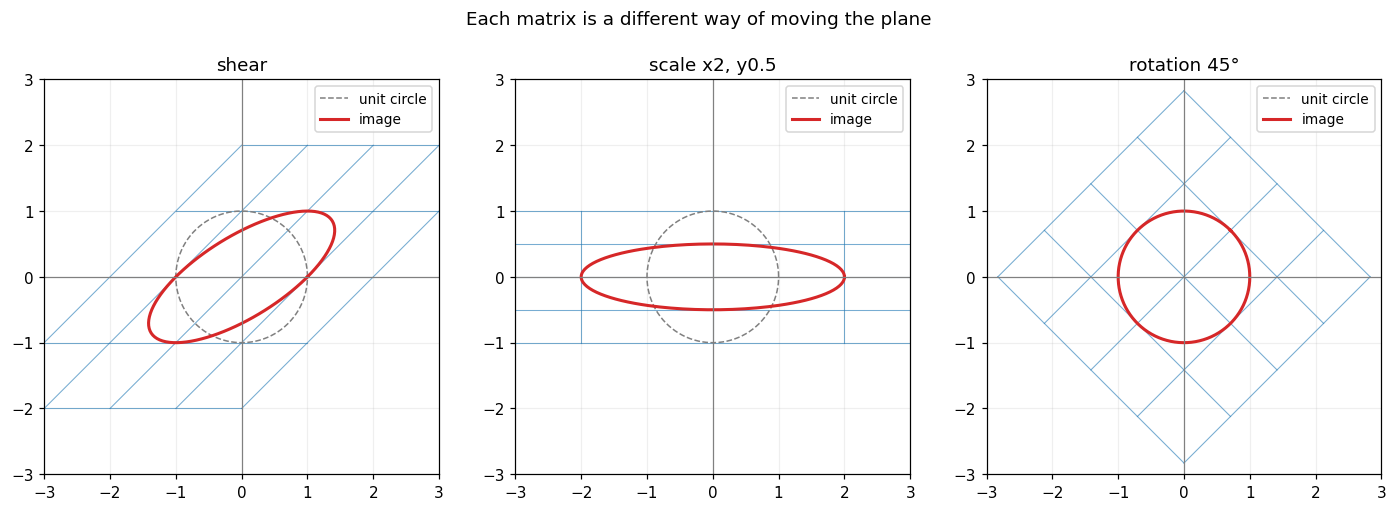

In [3]:
mats = {
    "kaydırma (shear)":            np.array([[1, 1], [0, 1]]),
    "ölçek x2, y0.5":   np.array([[2, 0], [0, 0.5]]),
    "döndürme 45°":     np.array([[np.cos(np.pi/4), -np.sin(np.pi/4)],
                                  [np.sin(np.pi/4),  np.cos(np.pi/4)]]),
}
fig, axes = plt.subplots(1, 3, figsize=(13, 4.3))
for ax, (name, M) in zip(axes, mats.items()):
    plot_transformation(M, ax=ax, grid_range=2)
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_title(name)
plt.suptitle("Her matris, düzlemi hareket ettirmenin farklı bir yoludur", y=1.03)
plt.tight_layout(); plt.show()

## 3. Bileşke = matris çarpımı

Önce $B$ dönüşümünü, *sonra* $A$'yı uygulamak, tek bir $AB$ matrisini uygulamakla aynıdır:

$$ A(B\mathbf{x}) = (AB)\mathbf{x} $$

Matris çarpımının o tuhaf şekilde tanımlanmasının asıl nedeni budur — "$B$'yi yap, sonra $A$'yı yap"ı
kodlaması gerekir. Sıra önemlidir: genelde $AB \ne BA$'dır, çünkü önce-döndürüp-sonra-kaydırmak,
önce-kaydırıp-sonra-döndürmekle aynı değildir. Hadi matris çarpımını sıfırdan uygulayalım ve
her iki gerçeği de doğrulayalım.

In [4]:
def matmul(A, B):
    A, B = np.asarray(A, float), np.asarray(B, float)
    m, k = A.shape
    k2, n = B.shape
    assert k == k2, "iç boyutlar eşleşmelidir"
    C = np.zeros((m, n))
    for i in range(m):
        for j in range(n):
            for t in range(k):
                C[i, j] += A[i, t] * B[t, j]
    return C

A = mats["döndürme 45°"]
B = mats["kaydırma (shear)"]
check("matmul == @", matmul(A, B), A @ B)

x = np.array([1.0, 1.0])
print("A(Bx)      =", A @ (B @ x))
print("(AB)x      =", (A @ B) @ x, " → aynı (bileşke)")
print("AB == BA ? ", np.allclose(A @ B, B @ A), " → sıra önemlidir")

[PASS] matmul == @                      max|Δ| = 0.00e+00
A(Bx)      = [0.707 2.121]
(AB)x      = [0.707 2.121]  → same (composition)
AB == BA ?  False  → order matters


## 4. Determinant = alanın ne kadar ölçeklendiği

Bir 2×2 matrisinin **determinantı**, alanı nasıl ölçeklediğini ölçer; yönelim için bir işaretle birlikte:

$$ \det\begin{pmatrix} a & b \\ c & d \end{pmatrix} = ad - bc $$

- $|\det A|$ = alanların büyüdüğü ya da küçüldüğü çarpan.
- $\det A < 0$ = dönüşüm yönelimi **çevirir** (bir yansıma).
- $\det A = 0$ = uzay bir doğruya **çöker** — dönüşüm tersinir değildir. Bu,
  Ders 1'de bağımlı vektörlerle gördüğümüz aynı "geren çökmesi"dir ve bir sonraki defterdeki
  **rank**ın tohumudur.

**İz (trace)** ($a + d$, köşegen toplamı), özdeğerlerin toplamına eşit olan tamamlayıcı bir niceliktir
(Hafta 5). Hadi alan yorumunu doğrudan doğrulayalım.

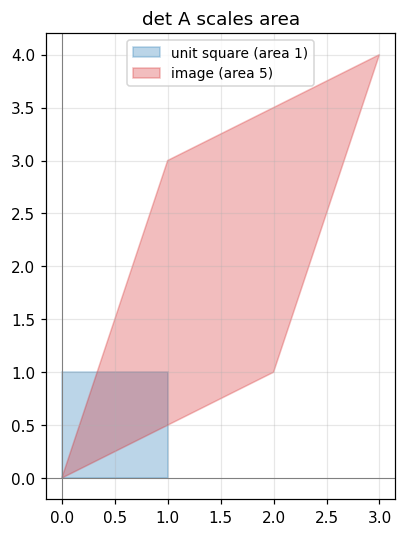

[PASS] det2 == np.linalg.det            max|Δ| = 8.88e-16
trace(A) = 5.0


In [5]:
def det2(M):
    (a, b), (c, d) = M
    return a * d - b * c

A = np.array([[2.0, 1.0], [1.0, 3.0]])

# birim karenin köşeleri → dönüştürülmüş paralelkenar; alan = |det|
square = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]]).T
trans = A @ square

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.fill(square[0], square[1], alpha=0.3, color="C0", label="birim kare (alan 1)")
ax.fill(trans[0], trans[1], alpha=0.3, color="C3",
        label=f"görüntü (alan {abs(det2(A)):.0f})")
ax.axhline(0, color="grey", lw=0.7); ax.axvline(0, color="grey", lw=0.7)
ax.set_aspect("equal"); ax.grid(True, alpha=0.3); ax.legend(fontsize=9)
ax.set_title("det A alanı ölçekler")
plt.show()

check("det2 == np.linalg.det", det2(A), np.linalg.det(A))
print("iz(A) =", np.trace(A))

## 5. Bunun makine öğrenmesinde karşımıza çıktığı yer

- **Bir sinir ağı katmanı, bir matris dönüşümüdür** ($\mathbf{h} = W\mathbf{x} + \mathbf{b}$),
  ardından bir doğrusal-olmayanlık gelir. Her katman, kelimenin tam anlamıyla veri uzayını hareket ettirir ve yeniden şekillendirir.
- **Döndürme/ölçekleme matrisleri**, veri artırmada, beyazlatmada (whitening) ve PCA'in gerçekleştirdiği
  baz değiştirmede karşımıza çıkar.
- **Sıfır determinant**, tekil (tersinmez) bir dönüşüme işaret eder — kararsız en küçük kareler ve
  eşdoğrusal (collinear) özniteliklerin arkasındaki sayısal uyarı işareti.

Hızlı gösterim: bir nokta kümesini dönüştüren tek bir lineer katman.

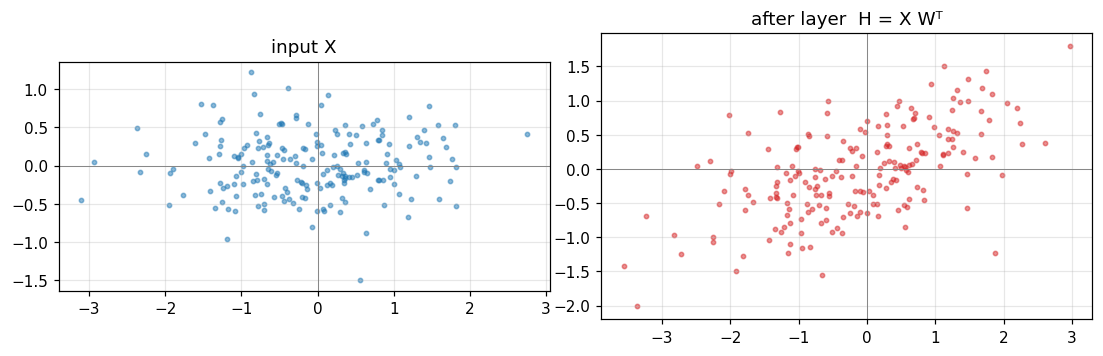

In [6]:
rng = np.random.default_rng(0)
X = rng.normal(size=(200, 2)) @ np.array([[1.0, 0.0], [0.0, 0.4]])  # düz bir bulut

W = np.array([[1.2, -0.8], [0.5, 1.0]])     # "katman ağırlıkları"
H = X @ W.T                                  # dönüştürülmüş aktivasyonlar

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].scatter(X[:, 0], X[:, 1], s=8, alpha=0.5, color="C0"); axes[0].set_title("girdi X")
axes[1].scatter(H[:, 0], H[:, 1], s=8, alpha=0.5, color="C3"); axes[1].set_title("katmandan sonra  H = X Wᵀ")
for ax in axes:
    ax.axhline(0, color="grey", lw=0.6); ax.axvline(0, color="grey", lw=0.6)
    ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Alıştırmalar

1. **Birim matris ve determinantı.** Birim matris $I$ hangi dönüşümdür? $\det I$ nedir ve geometrik olarak neden bu değer olmak zorundadır?
2. **Çevirmeyi bul.** $\det < 0$ olan bir 2×2 matris oluşturun ve ızgarayı yansıttığını görsel olarak doğrulayın.
3. **Değişme özelliğinin olmaması.** Bir döndürme $R$ ve bir ölçekleme $S$ seçin. $RS \ne SR$ olduğunu gösterin ve iki sıranın neden farklı göründüğünü kelimelerle açıklayın.

In [7]:
# === Çözümler (önce kendiniz deneyin!) ===

# 1. Birim matris her vektörü değişmeden bırakır; alanı 1 ile ölçekler ⇒ det = 1.
I = np.eye(2)
print("det(I) =", det2(I), " (birim matris hiçbir şeyi değiştirmez, alan çarpanı 1)")

# 2. Negatif determinant ⇒ yansıma
F = np.array([[1.0, 0.0], [0.0, -1.0]])   # x ekseninde çevirme
print("det(F) =", det2(F), " → yansıma")

# 3.
R = np.array([[0, -1], [1, 0]])           # 90° döndürme
S = np.array([[2, 0], [0, 1]])            # x'i ger
print("RS == SR ?", np.allclose(R @ S, S @ R))
print("RS =\n", R @ S, "\nSR =\n", S @ R)

det(I) = 1.0  (identity changes nothing, area factor 1)
det(F) = -1.0  → reflection
RS == SR ? False
RS =
 [[ 0 -1]
 [ 2  0]] 
SR =
 [[ 0 -2]
 [ 1  0]]


## Özet ve sırada ne var

Bir matris bir lineer dönüşüm *dür*; sütunları baz vektörlerinin nereye düştüğünü söyler; bileşke
çarpmadır; ve determinant alanın nasıl ölçeklendiğini bildirir (sıfır ⇒ çökme ⇒ tersinmez).

**Sırada — `04_rank_temel_alt_uzaylar.ipynb`:** bir dönüşüm uzayı çökerttiğinde, her şey *nereye*
düşer ve *ne* sıfıra ezilir? Bu sorular, **dört temel alt uzayı** ve **rank** kavramını tanımlar.

---
*Makine Öğrenmesi için Lineer Cebir · Hafta 2 · Ders 3*